# Computer Price Prediction — Exploration

Exploratory companion to the modular pipeline in `src/`. All loading,
feature engineering, and modeling logic is imported from `src/` rather than
duplicated here — see `src/data_loader.py`, `src/features.py`, `src/model.py`.

Run `python -m src.train` from the repo root for the full reproducible
training pipeline (algorithm comparison, charts, saved artifacts).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.data_loader import load_data, split_features_target
from src.features import SpecFeatureEncoder
from src.model import PricePredictor, make_regressor

## Load and inspect the data

In [2]:
df = load_data()
print(df.shape)
df.head()

(100000, 33)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [3]:
df['price'].describe()

count    100000.000000
mean       1928.764220
std         580.492689
min         372.990000
25%        1503.990000
50%        1863.990000
75%        2287.990000
max       10984.990000
Name: price, dtype: float64

In [4]:
# Categorical cardinality: `model` is ~unique per row (a row ID in disguise)
# and `cpu_model` has ~27k values. Both are dropped/replaced by the encoder.
df.select_dtypes(include='object').nunique().sort_values(ascending=False)

model           99036
cpu_model       26971
gpu_model          49
brand              10
form_factor        10
display_type        6
resolution          6
os                  4
gpu_brand           4
storage_type        4
wifi                4
cpu_brand           3
device_type         2
dtype: int64

## Encode features

`SpecFeatureEncoder` drops the ID-like `model` column, reduces `cpu_model`
to a 17-value `cpu_family`, converts `resolution` to megapixels, and one-hot
encodes the remaining low-cardinality categoricals
(`handle_unknown='ignore'`, so unseen categories don't crash inference).
It is fit on the training split only — no test-set information leaks in.

In [5]:
from sklearn.model_selection import train_test_split

X_raw, y = split_features_target(df)
raw_train, raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

encoder = SpecFeatureEncoder().fit(raw_train)
X_train = encoder.transform(raw_train)
X_test = encoder.transform(raw_test)
X_train.shape

(80000, 133)

## Train and evaluate

In [6]:
predictor = PricePredictor(algorithm='hist_gradient_boosting').train(X_train, y_train)

from sklearn.metrics import mean_absolute_error, r2_score
intervals = predictor.predict_with_confidence(X_test)
print('R2 :', r2_score(y_test, intervals['price']))
print('MAE:', mean_absolute_error(y_test, intervals['price']))
print('90% interval coverage:',
      ((y_test >= intervals['lower']) & (y_test <= intervals['upper'])).mean())

R2 : 0.8799550117317078
MAE: 139.42340704231668
90% interval coverage: 0.87825


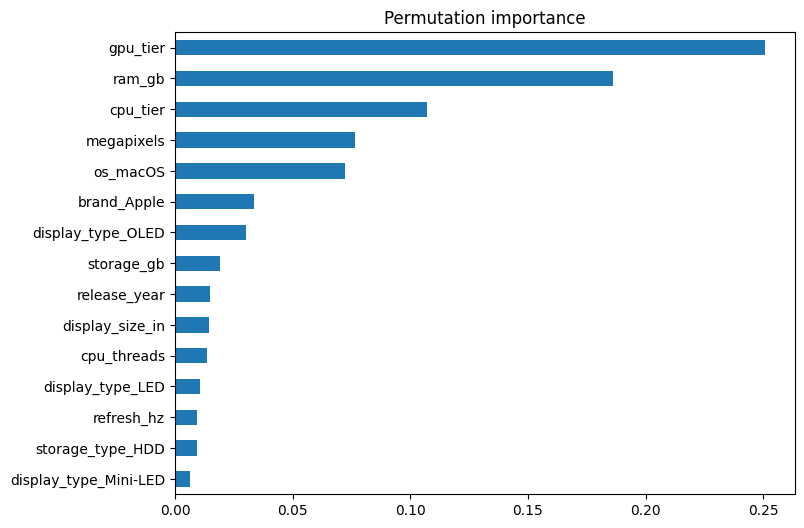

In [7]:
importance = predictor.feature_importance(X_test, y_test)
importance.head(15).iloc[::-1].plot.barh(figsize=(8, 6), title='Permutation importance');

## Predict a single configuration

The same encoder handles raw user input at inference time.

In [8]:
from src.model import predict_from_specs

specs = dict(encoder.defaults_by_device_['Laptop'])
specs.update(device_type='Laptop', brand='MSI', cpu_family='Intel i7',
             gpu_model='RTX 40 80', ram_gb=32, storage_gb=1024)
specs.update(encoder.cpu_profiles_['Intel i7'])
specs.update(encoder.gpu_profiles_['RTX 40 80'])

predict_from_specs(predictor, encoder, specs)

{'price': 2005.3704226448424,
 'lower': 1777.2995095002536,
 'upper': 2289.98608893124}

In [9]:
predictor.explain_prediction(encoder, specs)

,spec,value,delta
0,gpu_model,RTX 40 80,189.598617
1,cpu_family,Intel i7,100.757777
2,storage_gb,1024,78.114271
3,brand,MSI,49.031595
